### Simple use of Autoencoder for Anomaly Detection of Univariate Synthetized dataset
- References: 
    - ["Outlier Detection With Autoencoders", Dr. Robert Kübler in TDS, 2022](https://towardsdatascience.com/outlier-detection-with-autoencoders-6c7ac3e2aa90/)

    - ["Anomaly Detection with Auto-Enc", Robin Teuwens in Kaggle, 2021](https://www.kaggle.com/code/robinteuwens/anomaly-detection-with-auto-encoders/notebook)

#### Define enums

In [1]:
from enum import Enum

class ThresholdType(Enum):
    fixed=1
    three_sigma=2
    mad=3

#### Define global configurations

In [2]:
from dataclasses import dataclass

@dataclass
class Configs:
    num_normal_points: int = 1000
    num_outliers: int = 50
    random_seed: int = 100
    pi: float = 3.14
    noise_stddev: float = 0.05
    noise_min_value: float = -2.0
    noise_max_value: float = 2.0
    is_outlier_inside_circle: bool = True
    early_stop_patience = 50
    threshold_type: ThresholdType = ThresholdType.three_sigma
    sigma_multiplier: float = 1.0   
    fixed_threshold_value: float = 0.01
    encoding_dim = 16
    output_dim = 2
    validation_split = 0.2
    bottleneck_dim = 1
    num_epochs = 500
    

configs = Configs()

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

%matplotlib inline

tf.random.set_seed(configs.random_seed)

t = tf.expand_dims(tf.linspace(0., 2*configs.pi, configs.num_normal_points), -1)
noise = tf.random.normal(
    (configs.num_normal_points, 2), 
    stddev=configs.noise_stddev,
    seed=configs.random_seed
    )
predicted_points = tf.concat([tf.cos(t), tf.sin(t)], axis=1) + noise



#### Plot the "normal" dataset i.e., it has no anomalous points

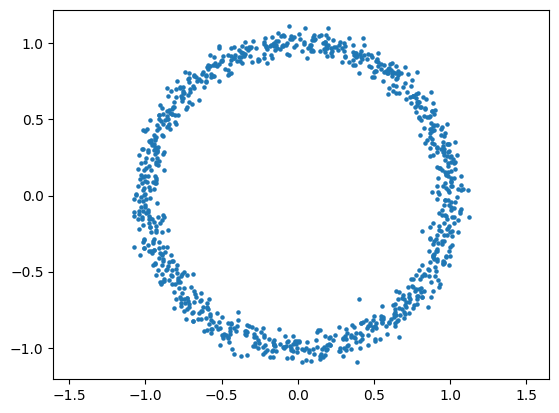

In [4]:
# Visualize the data
import matplotlib.pyplot as plt 
plt.scatter(predicted_points[:, 0], predicted_points[:, 1], s=5)
plt.axis('equal')
plt.show()

#### Now we add some noise (anomalous points to the dataset)

In [5]:
tf.random.set_seed(configs.random_seed)

# Generate outliers that are outside the [-1, +1] range in at least one coordinate
def sample_outliers_outside_unit_box(num_outliers, minval, maxval):
    outliers = tf.zeros((0, 2), dtype=tf.float32)
    while outliers.shape[0] < num_outliers:
        candidates = tf.random.uniform(
            (num_outliers * 2, 2),
            minval=minval,
            maxval=maxval,
            dtype=tf.float32
        )
        keep = tf.logical_or(
            tf.abs(candidates[:, 0]) > 1.0,
            tf.abs(candidates[:, 1]) > 1.0,
        )
        selected = tf.boolean_mask(candidates, keep)
        outliers = tf.concat([outliers, selected], axis=0)
    return outliers[:num_outliers]

# Add function to generate outliers for x and y with values between -2 and +2 but with a lower probability of being close to the unit circle
def sample_outliers_with_low_probability_inside_unit_circle(
    num_outliers,
    minval,
    maxval,
    inside_keep_prob=0.2,
    batch_factor=4
):
    outliers = tf.zeros((0, 2), dtype=tf.float32)
    while outliers.shape[0] < num_outliers:
        candidates = tf.random.uniform(
            (num_outliers * batch_factor, 2),
            minval=minval,
            maxval=maxval,
            dtype=tf.float32
        )

        inside_unit_circle = tf.norm(candidates, axis=1) <= 1.0
        keep_inside = tf.random.uniform((tf.shape(candidates)[0],), dtype=tf.float32) < inside_keep_prob
        keep_mask = tf.logical_or(~inside_unit_circle, keep_inside)

        selected = tf.boolean_mask(candidates, keep_mask)
        outliers = tf.concat([outliers, selected], axis=0)

    return outliers[:num_outliers]

if configs.is_outlier_inside_circle:
    outliers = sample_outliers_with_low_probability_inside_unit_circle(
        configs.num_outliers,
        configs.noise_min_value,
        configs.noise_max_value
    )
else:
    outliers = sample_outliers_outside_unit_box(
        configs.num_outliers,
        configs.noise_min_value,
        configs.noise_max_value
    )

points_with_outliers = tf.concat(
    [
        predicted_points,
        outliers
    ],
    axis=0
)

# Add tensor to represent labels (0 for normal, 1 for outliers)
labels = tf.concat([
    tf.zeros((configs.num_normal_points, 1)),  # 0 for normal points
    tf.ones((configs.num_outliers, 1))     # 1 for outliers
], axis=0)




#### Also let us visualize the dataset with the added anomalies

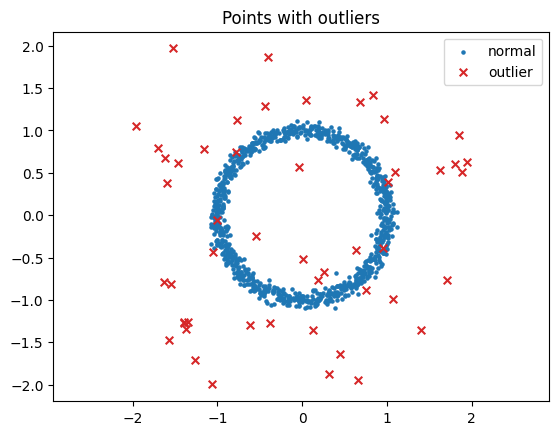

In [6]:
# Visualize the data
import matplotlib.pyplot as plt 

def plot_points(points, labels=None, title="Points with outliers"):
    pts = points.numpy() if hasattr(points, "numpy") else points
    if labels is not None:
        lbl = labels.numpy().reshape(-1) if hasattr(labels, "numpy") else labels
        normal_mask = lbl == 0
        outlier_mask = lbl == 1
        plt.scatter(pts[normal_mask, 0], pts[normal_mask, 1], s=5, c="tab:blue", label="normal")
        plt.scatter(pts[outlier_mask, 0], pts[outlier_mask, 1], s=30, c="tab:red", marker="x", label="outlier")
        plt.legend()
    else:
        plt.scatter(pts[:, 0], pts[:, 1], s=5)
    plt.axis("equal")
    plt.title(title)
    plt.show()

plot_points(points_with_outliers, labels)



#### Create Autoencoder model to predict outliers in the dataset - anomaly detector

In [14]:
tf.random.set_seed(configs.random_seed)

def train_autoencoder_anomaly_detection(
    nomal_points, 
    encoding_dim: int = configs.encoding_dim, 
    bottleneck_dim: int = configs.bottleneck_dim,
    output_dim: int = configs.output_dim,
    validation_split: float = configs.validation_split,
    epochs: int = configs.num_epochs   
    ) -> tuple[tf.keras.Model, tf.keras.callbacks.History]:
    shuffled_points = tf.random.shuffle(nomal_points)

    encoder = tf.keras.Sequential([
    tf.keras.layers.Dense(encoding_dim, activation="relu"),
    tf.keras.layers.Dense(encoding_dim, activation="relu"),
    tf.keras.layers.Dense(encoding_dim, activation="relu"),
    tf.keras.layers.Dense(bottleneck_dim) # one-dimensional bottleneck layer
    ])

    decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(encoding_dim, activation="relu"),
    tf.keras.layers.Dense(encoding_dim, activation="relu"),
    tf.keras.layers.Dense(encoding_dim, activation="relu"),
    tf.keras.layers.Dense(output_dim) # decode to two dimensions again
    ])

    autoencoder = tf.keras.Sequential([encoder, decoder])
    autoencoder.compile(loss="mse")
    autoencoder.summary()
    
    # tf.keras.utils.plot_model(autoencoder)

    early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=configs.early_stop_patience,
    verbose=1, 
    mode='min',
    restore_best_weights=True
    )
    history = autoencoder.fit(
    x=shuffled_points,
    y=shuffled_points,
    validation_split=validation_split,
    callbacks=[early_stop],
    epochs=epochs,
    verbose=2,    
    )
    return autoencoder, history

def plot_training_loss_curve(history, title="Autoencoder training/validation loss"):
    plt.plot(history.history["loss"], label="train_loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="val_loss")
        plt.xlabel("Epoch")
        plt.ylabel("MSE loss")
        plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


#### Run the Anomaly Detection model train-validation cycle

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
25/25 - 1s - 41ms/step - loss: 0.4745 - val_loss: 0.4261
Epoch 2/500
25/25 - 0s - 5ms/step - loss: 0.3795 - val_loss: 0.3136
Epoch 3/500
25/25 - 0s - 4ms/step - loss: 0.2831 - val_loss: 0.2542
Epoch 4/500
25/25 - 0s - 4ms/step - loss: 0.2557 - val_loss: 0.2456
Epoch 5/500
25/25 - 0s - 4ms/step - loss: 0.2507 - val_loss: 0.2415
Epoch 6/500
25/25 - 0s - 4ms/step - loss: 0.2470 - val_loss: 0.2387
Epoch 7/500
25/25 - 0s - 4ms/step - loss: 0.2433 - val_loss: 0.2358
Epoch 8/500
25/25 - 0s - 4ms/step - loss: 0.2387 - val_loss: 0.2325
Epoch 9/500
25/25 - 0s - 3ms/step - loss: 0.2332 - val_loss: 0.2272
Epoch 10/500
25/25 - 0s - 5ms/step - loss: 0.2262 - val_loss: 0.2199
Epoch 11/500
25/25 - 0s - 4ms/step - loss: 0.2180 - val_loss: 0.2117
Epoch 12/500
25/25 - 0s - 3ms/step - loss: 0.2082 - val_loss: 0.2003
Epoch 13/500
25/25 - 0s - 3ms/step - loss: 0.1969 - val_loss: 0.1874
Epoch 14/500
25/25 - 0s - 4ms/step - loss: 0.1839 - val_loss: 0.1728
Epoch 15/500
25/25 - 0s - 4ms/step - loss:

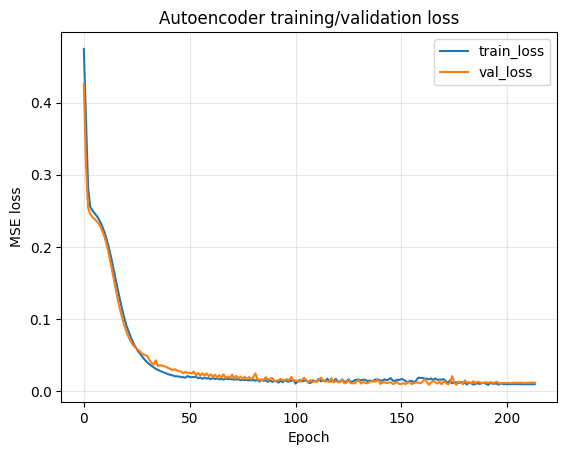

In [15]:
anomaly_detector, history = train_autoencoder_anomaly_detection(predicted_points)
plot_training_loss_curve(history)

#### Compute the recontruction error and reconstructed points using the trained model

In [9]:
def mad_score(reconstruction_errors):
    """
    Compute the Median Absolute Deviation (MAD) score for a set of points.
    Reference: https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm 
    """
    m = np.median(reconstruction_errors)
    ad = np.abs(reconstruction_errors - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

def compute_three_sigma_threshold(reconstruction_errors, sigma_multiplier: float = configs.sigma_multiplier):
    """
    Compute the threshold for anomaly detection using the mean and standard deviation of the reconstruction errors.
    """
    mean = np.mean(reconstruction_errors)
    std = np.std(reconstruction_errors)
    return mean + sigma_multiplier * std

def compute_reconstruction_errors(
        model: tf.keras.Model, 
        points_with_outliers: tf.Tensor ,
        threshold_type: ThresholdType = configs.threshold_type,
        ) -> tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    reconstructed_points = model(points_with_outliers)
    errors = tf.reduce_mean(tf.square(points_with_outliers - reconstructed_points), axis=1)

    match threshold_type:
        case ThresholdType.fixed:
            threshold = configs.fixed_threshold_value
        case ThresholdType.three_sigma:
            threshold = compute_three_sigma_threshold(errors)   
        case ThresholdType.mad:
            threshold = mad_score(errors)
        case _:
            raise ValueError(f"Unsupported threshold type: {threshold_type}")
    
    anomalous_mask = errors > threshold     
    
    return errors, reconstructed_points, anomalous_mask

errors, reconstructed_points, anomalous_mask = compute_reconstruction_errors(anomaly_detector, points_with_outliers)

#### Plot the predicted anomalies (without threshold)

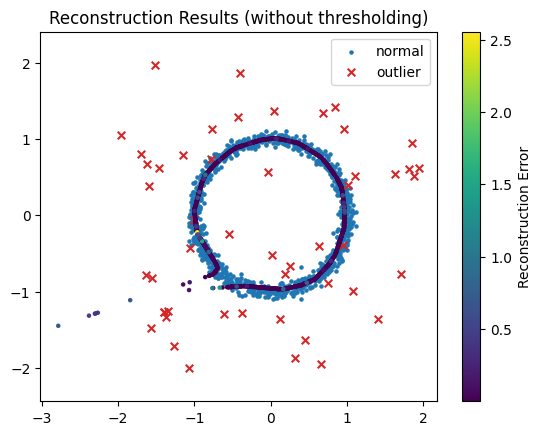

In [10]:
def plot_reconstruction_results_no_threshold(
        original_points, 
        reconstructed_points, 
        errors, 
        labels=None, 
        title="Reconstruction Results (without thresholding)"):
    orig_pts = original_points.numpy() if hasattr(original_points, "numpy") else original_points
    recon_pts = reconstructed_points.numpy() if hasattr(reconstructed_points, "numpy") else reconstructed_points
    err = errors.numpy() if hasattr(errors, "numpy") else errors

    if labels is not None:
        lbl = labels.numpy().reshape(-1) if hasattr(labels, "numpy") else labels
        normal_mask = lbl == 0
        outlier_mask = lbl == 1
        plt.scatter(orig_pts[normal_mask, 0], orig_pts[normal_mask, 1], s=5, c="tab:blue", label="normal")
        plt.scatter(orig_pts[outlier_mask, 0], orig_pts[outlier_mask, 1], s=30, c="tab:red", marker="x", label="outlier")
        plt.legend()
    
    # Plot reconstructed points with color based on reconstruction error
    plt.scatter(recon_pts[:, 0], recon_pts[:, 1], s=5, c=err, cmap="viridis", label="reconstructed")
    plt.colorbar(label="Reconstruction Error")
    plt.axis("equal")
    plt.title(title)
    plt.show()


plot_reconstruction_results_no_threshold(points_with_outliers, reconstructed_points, errors, labels)

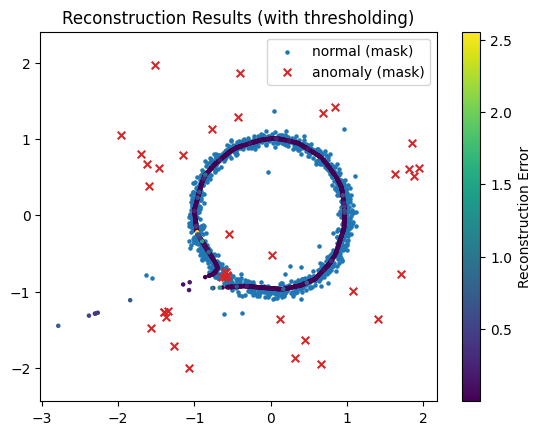

In [11]:
# Visualize the data, plot the original points, reconstructed points, and highlight the outliers based on reconstruction error
def plot_reconstruction_results_with_threshold(
    original_points,
    reconstructed_points,
    errors,
    labels=None,
    anomalous_mask=None,
    title="Reconstruction Results (with thresholding)"
):
    orig_pts = original_points.numpy() if hasattr(original_points, "numpy") else original_points
    recon_pts = reconstructed_points.numpy() if hasattr(reconstructed_points, "numpy") else reconstructed_points
    err = errors.numpy() if hasattr(errors, "numpy") else errors

    if anomalous_mask is not None:
        mask = anomalous_mask.numpy().reshape(-1) if hasattr(anomalous_mask, "numpy") else anomalous_mask
        normal_mask = ~mask
        plt.scatter(orig_pts[normal_mask, 0], orig_pts[normal_mask, 1], s=5, c="tab:blue", label="normal (mask)")
        plt.scatter(orig_pts[mask, 0], orig_pts[mask, 1], s=30, c="tab:red", marker="x", label="anomaly (mask)")
        plt.legend()
    elif labels is not None:
        lbl = labels.numpy().reshape(-1) if hasattr(labels, "numpy") else labels
        normal_mask = lbl == 0
        outlier_mask = lbl == 1
        plt.scatter(orig_pts[normal_mask, 0], orig_pts[normal_mask, 1], s=5, c="tab:blue", label="normal")
        plt.scatter(orig_pts[outlier_mask, 0], orig_pts[outlier_mask, 1], s=30, c="tab:red", marker="x", label="outlier")
        plt.legend()
    else:
        plt.scatter(orig_pts[:, 0], orig_pts[:, 1], s=5, c="tab:gray", label="original")
        plt.legend()

    plt.scatter(recon_pts[:, 0], recon_pts[:, 1], s=5, c=err, cmap="viridis", label="reconstructed")
    cbar = plt.colorbar()
    cbar.set_label("Reconstruction Error")
    plt.axis("equal")
    plt.title(title)
    plt.show()

plot_reconstruction_results_with_threshold(points_with_outliers, reconstructed_points, errors, labels=labels, anomalous_mask=anomalous_mask)

#### Performance evaluation of the anomaly detector
- Plot the distributions of the normal and predicted anomalies
- We use the n-sigma threshold error i.e., mean + n * sigma to classify dataset based on reconstruction error:
  - Typical value of n is 3 for most general anomaly detection problems.
  - This depends on the problem specifics and normally requires experimentation
  - I have used n = 1 for this problem 
  - Points greater than mean + 3 sigma will be classified as anomalies/outliers
- Plot the Confusion matrix

Normal points - min error: 0.0000, max error: 1.4422
Anomalous points - min error: 0.0002, max error: 2.5546


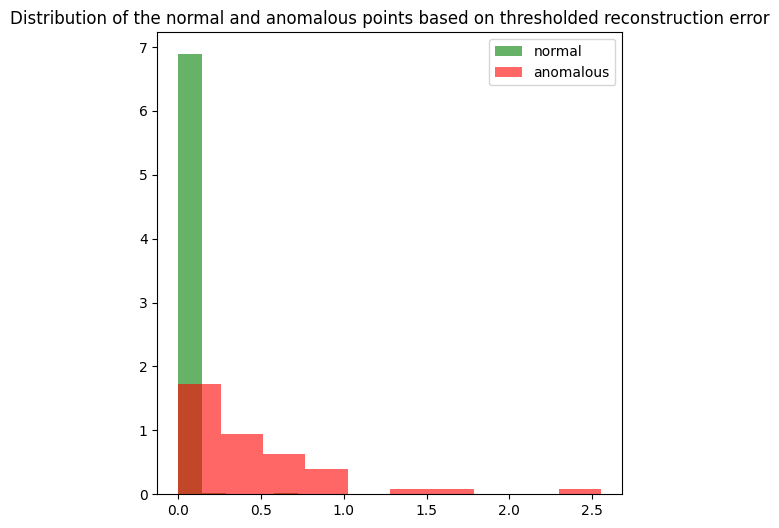

In [12]:
def compute_normal_and_anomalous_distributions(labels, errors):
    normal = errors.numpy()[labels.numpy().reshape(-1) == 0]
    anomalous = errors.numpy()[labels.numpy().reshape(-1) == 1]
    print(f"Normal points - min error: {np.min(normal):.4f}, max error: {np.max(normal):.4f}")
    print(f"Anomalous points - min error: {np.min(anomalous):.4f}, max error: {np.max(anomalous):.4f}")

    fig, ax = plt.subplots(figsize=(6,6))

    ax.hist(normal, bins=10, density=True, label="normal", alpha=0.6, color="green")
    ax.hist(anomalous, bins=10, density=True, label="anomalous", alpha=.6, color="red")

    plt.title("Distribution of the normal and anomalous points based on thresholded reconstruction error")
    plt.legend()
    plt.show()

compute_normal_and_anomalous_distributions(labels, errors)


Classification Report for Anomaly Detection:
              precision    recall  f1-score   support

      normal       0.98      0.99      0.99      1000
     anomaly       0.85      0.66      0.74        50

    accuracy                           0.98      1050
   macro avg       0.91      0.83      0.87      1050
weighted avg       0.98      0.98      0.98      1050

Weighted F1 Score: 0.9768


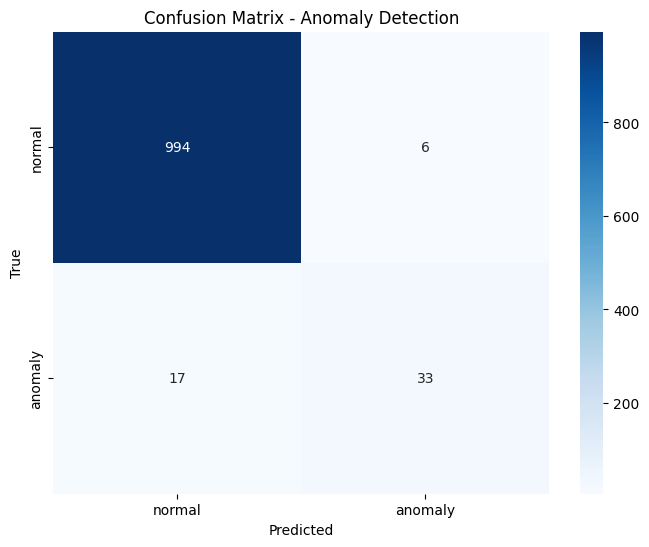

In [13]:
def compute_anomaly_detection_metrics(labels, anomalous_mask):
    problem_type =  "Anomaly Detection"   
    lbl = labels.numpy().reshape(-1) if hasattr(labels, "numpy") else labels
    mask = anomalous_mask.numpy().reshape(-1) if hasattr(anomalous_mask, "numpy") else anomalous_mask
    y_true = lbl
    y_pred = mask.astype(int)    
    
    report = classification_report(y_true, y_pred, target_names=["normal", "anomaly"])
    
    print(f"\nClassification Report for {problem_type}:")
    print(report)

    y_true_text = ["normal" if t == 0 else "anomaly" for t in y_true]
    y_pred_text = ["normal" if p == 0 else "anomaly" for p in y_pred]
    labels = ["normal", "anomaly"]

    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"Weighted F1 Score: {f1:.4f}")

    cm = confusion_matrix(y_true_text, y_pred_text, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="", cmap="Blues")
    # Manually set the labels
    plt.gca().set_xticklabels(["normal", "anomaly"])
    plt.gca().set_yticklabels(["normal", "anomaly"])

    plt.title(f"Confusion Matrix - {problem_type}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

compute_anomaly_detection_metrics(labels, anomalous_mask)